In [1]:
import os
import json
from sklearn.decomposition import PCA
from collections import defaultdict
import torch
import matplotlib.pyplot as plt
import numpy as np

In [109]:
run_dir = "data/runs_qwen3_fixed"
with open(f"{run_dir}/runs_summary.jsonl", "r") as f:
    summary_data = [json.loads(line) for line in f]

In [110]:
def load_embedding(run_dir, run_name):
    with open(os.path.join(run_dir, run_name, "special_token_embeddings.pt"), "rb") as f:
        return torch.load(f)

In [123]:
def plot_pca(pca_points, dimensions=2, labels=None, title="PCA Plot", save_path=None):
    """
    Plots PCA points in 2D or 3D.

    Parameters:
    - pca_points: Array-like, shape (n_samples, n_components). The PCA transformed data.
    - dimensions: int, either 2 or 3. The dimensionality of the plot.
    - labels: Array-like, shape (n_samples,), optional. Class labels for coloring the points.
    - title: str, optional. Title of the plot.
    """
    # Ensure inputs are numpy arrays for easier indexing
    pca_points = np.array(pca_points)
    
    if dimensions not in [2, 3]:
        raise ValueError("Dimensionality must be exactly 2 or 3.")
    
    if pca_points.shape[1] < dimensions:
        raise ValueError(f"Data has {pca_points.shape[1]} components, but {dimensions} are required for plotting.")

    fig = plt.figure(figsize=(7, 5))

    # --- 2D Plotting ---
    if dimensions == 2:
        ax = fig.add_subplot(111)
        x, y = pca_points[:, 0], pca_points[:, 1]
        
        if labels is not None:
            labels = np.array(labels)
            unique_labels = np.unique(labels)
            for label in unique_labels:
                idx = (labels == label)
                ax.scatter(x[idx], y[idx], label=str(label), alpha=0.7, edgecolors='w', s=60)
            ax.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.scatter(x, y, alpha=0.7, edgecolors='w', s=60)
            
        ax.set_xlabel("Principal Component 1")
        ax.set_ylabel("Principal Component 2")

    # --- 3D Plotting ---
    elif dimensions == 3:
        ax = fig.add_subplot(111, projection='3d')
        x, y, z = pca_points[:, 0], pca_points[:, 1], pca_points[:, 2]
        
        if labels is not None:
            labels = np.array(labels)
            unique_labels = np.unique(labels)
            for label in unique_labels:
                idx = (labels == label)
                ax.scatter(x[idx], y[idx], z[idx], label=str(label), alpha=0.7, edgecolors='w', s=60)
            ax.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.scatter(x, y, z, alpha=0.7, edgecolors='w', s=60)
            
        ax.set_xlabel("Principal Component 1")
        ax.set_ylabel("Principal Component 2")
        ax.set_zlabel("Principal Component 3")

    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [124]:
points = []
for run in summary_data:
    run_result = dict()
    run_name = run["run_name"]
    embedding = load_embedding(run_dir, run_name)
    run_result["embedding"] = embedding["embeddings"].numpy()
    run_result["base_persona_id"] = run["base_persona_id"]
    run_result["style_id"] = run["style_id"]
    run_result["held_out_topic_id"] = run["held_out_topic_id"]
    points.append(run_result)

In [125]:
dimensions = 3
pca = PCA(n_components=dimensions)
# pca_result = pca.fit_transform([point["embedding"][0] for point in points])

stacked_embeddings = np.array([np.reshape(point["embedding"], (1, -1)) for point in points])
stacked_embeddings = np.array(stacked_embeddings).squeeze()
pca_result = pca.fit_transform(stacked_embeddings)

# mean_embeddings = np.array([point["embedding"].mean(axis=0) for point in points])
# pca_result = pca.fit_transform(mean_embeddings)

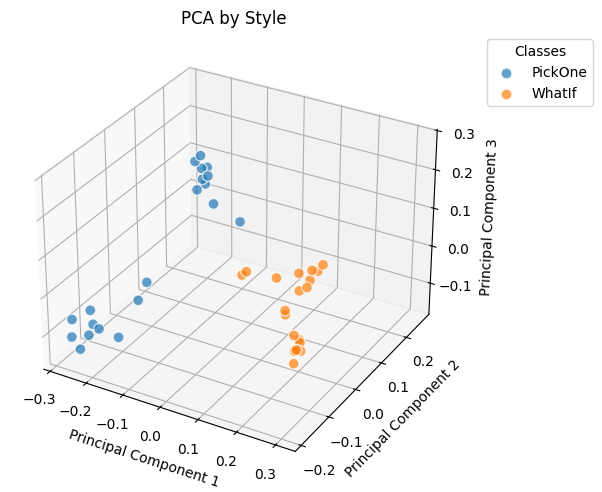

In [126]:
labels = [result["style_id"] for result in points]
plot_pca(pca_result, dimensions=dimensions, labels=labels, title="PCA by Style", save_path="plots/pca_by_style.png")

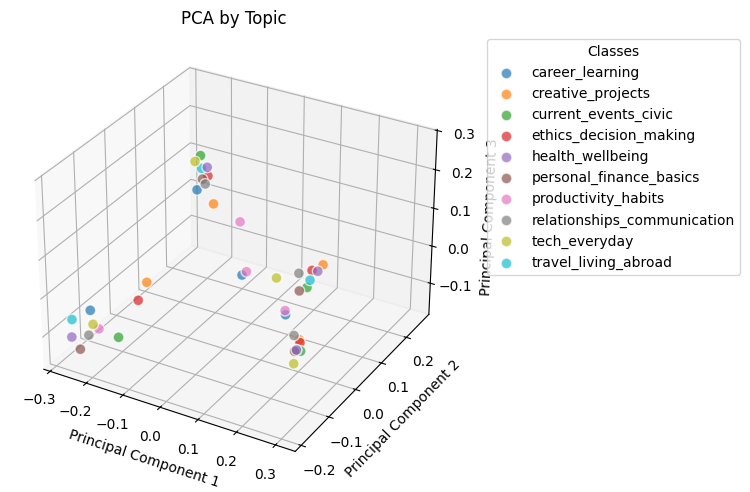

In [127]:
labels = [result["held_out_topic_id"] for result in points]
plot_pca(pca_result, dimensions=dimensions, labels=labels, title="PCA by Topic", save_path="plots/pca_by_topic.png")

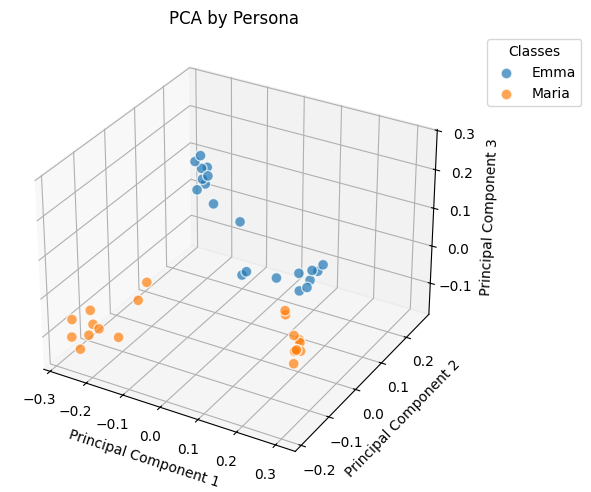

In [128]:
labels = [result["base_persona_id"] for result in points]
plot_pca(pca_result, dimensions=dimensions, labels=labels, title="PCA by Persona", save_path="plots/pca_by_persona.png")

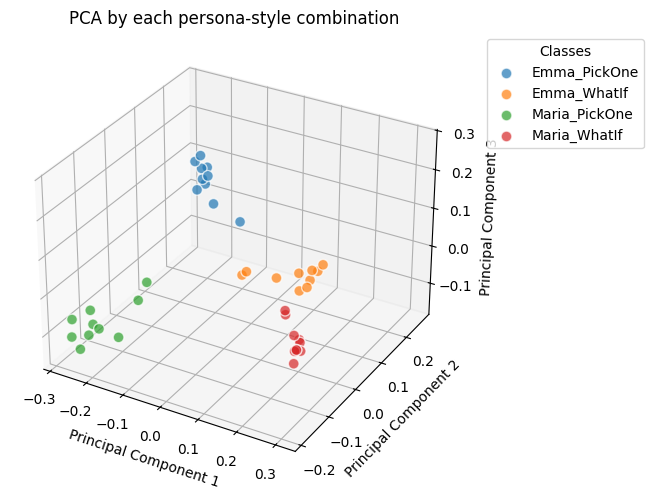

In [129]:
labels = [f'{result["base_persona_id"]}_{result["style_id"]}' for result in points]
plot_pca(pca_result, dimensions=dimensions, labels=labels, title="PCA by each persona-style combination", save_path="plots/pca_by_persona_style.png")

# Cosine Similarity / Dot Product

In [98]:
def cosine_similarity(v1, v2):
  dot_product = np.dot(v1, v2)
  return dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2))

def dot(v1, v2):
    return np.dot(v1, v2)

def distance(v1, v2):
    return np.linalg.norm(v1 - v2)

In [99]:
mean_vectors_persona = defaultdict(list)
for point in points:
    persona_id = point["base_persona_id"]
    mean_vector = point["embedding"].mean(axis=0)
    mean_vectors_persona[persona_id].append(mean_vector)

for persona_id, vectors in mean_vectors_persona.items():
    mean_vectors_persona[persona_id] = np.mean(vectors, axis=0)

print(cosine_similarity(mean_vectors_persona["Emma"], mean_vectors_persona["Maria"]))
print(dot(mean_vectors_persona["Emma"], mean_vectors_persona["Maria"]))
print(distance(mean_vectors_persona["Emma"], mean_vectors_persona["Maria"]))

0.935367
0.1382197
0.13820891


In [100]:
mean_vectors_style = defaultdict(list)
for point in points:
    style_id = point["style_id"]
    mean_vector = point["embedding"].mean(axis=0)
    mean_vectors_style[style_id].append(mean_vector)

for style_id, vectors in mean_vectors_style.items():
    mean_vectors_style[style_id] = np.mean(vectors, axis=0)

print(cosine_similarity(mean_vectors_style["WhatIf"], mean_vectors_style["PickOne"]))
print(dot(mean_vectors_style["WhatIf"], mean_vectors_style["PickOne"]))
print(distance(mean_vectors_style["WhatIf"], mean_vectors_style["PickOne"]))

0.9064779
0.13596877
0.16764656


In [101]:
mean_vectors_persona_style = defaultdict(list)
for point in points:
    style_id = point["style_id"]
    persona_id = point["base_persona_id"]
    full_name = f"{persona_id}_{style_id}"
    mean_vector = point["embedding"].mean(axis=0)
    mean_vectors_persona_style[full_name].append(mean_vector)

for key, vectors in mean_vectors_persona_style.items():
    mean_vectors_persona_style[key] = np.mean(vectors, axis=0)

In [102]:
keys = list(mean_vectors_persona_style.keys())
cosine_similarities = dict()
dot_products = dict()
distances = dict()

for i in range(len(keys)):
    for j in range(i, len(keys)):
        base_key = keys[i]
        ref_key = keys[j]

        cosine_similarities[f"{base_key}_{ref_key}"] = cosine_similarity(mean_vectors_persona_style[base_key], mean_vectors_persona_style[ref_key])
        dot_products[f"{base_key}_{ref_key}"] = dot(mean_vectors_persona_style[base_key], mean_vectors_persona_style[ref_key])
        distances[f"{base_key}_{ref_key}"] = distance(mean_vectors_persona_style[base_key], mean_vectors_persona_style[ref_key])

In [66]:
cosine_similarities

{'Emma_PickOne_Emma_PickOne': 1.0,
 'Emma_PickOne_Emma_WhatIf': 0.90931904,
 'Emma_PickOne_Maria_PickOne': 0.9060194,
 'Emma_PickOne_Maria_WhatIf': 0.8444581,
 'Emma_WhatIf_Emma_WhatIf': 1.0,
 'Emma_WhatIf_Maria_PickOne': 0.86016613,
 'Emma_WhatIf_Maria_WhatIf': 0.8573369,
 'Maria_PickOne_Maria_PickOne': 1.0000001,
 'Maria_PickOne_Maria_WhatIf': 0.80028015,
 'Maria_WhatIf_Maria_WhatIf': 1.0}

In [97]:
dot_products

{'Emma_PickOne_Emma_PickOne': 0.15444499,
 'Emma_PickOne_Emma_WhatIf': 0.14077683,
 'Emma_PickOne_Maria_PickOne': 0.1451593,
 'Emma_PickOne_Maria_WhatIf': 0.13360634,
 'Emma_WhatIf_Emma_WhatIf': 0.15518722,
 'Emma_WhatIf_Maria_PickOne': 0.1381436,
 'Emma_WhatIf_Maria_WhatIf': 0.13596952,
 'Maria_PickOne_Maria_PickOne': 0.1662038,
 'Maria_PickOne_Maria_WhatIf': 0.13134834,
 'Maria_WhatIf_Maria_WhatIf': 0.16207802}

In [103]:
distances

{'Emma_PickOne_Emma_PickOne': 0.0,
 'Emma_PickOne_Emma_WhatIf': 0.16756663,
 'Emma_PickOne_Maria_PickOne': 0.17415561,
 'Emma_PickOne_Maria_WhatIf': 0.22205932,
 'Emma_WhatIf_Emma_WhatIf': 0.0,
 'Emma_WhatIf_Maria_PickOne': 0.21237655,
 'Emma_WhatIf_Maria_WhatIf': 0.21289949,
 'Maria_PickOne_Maria_PickOne': 0.0,
 'Maria_PickOne_Maria_WhatIf': 0.25609595,
 'Maria_WhatIf_Maria_WhatIf': 0.0}